# Preprocessing and Windowing - Figshare Dataset

**Objective:** Prepare data for FoG detection through label creation, sliding windows, and LOSO splits.

**Process:**
1. Load dataset
2. Create binary labels
3. Generate sliding windows (4s at 64Hz, train 50% overlap / test 0% overlap)
4. Create LOSO splits
5. Save windowed data

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import LeaveOneGroupOut
import pickle

from loaders import FigshareDatasetLoader
from processing import WindowCreator

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 1. Load Dataset

In [2]:
# Load data (walking trials only)
loader = FigshareDatasetLoader('../../Datasets/Figshare a public dataset')
df = loader.load_all_data(verbose=True, trial_type='walking')

# Add subject and session string identifiers
df['subject'] = df['subject_id'].apply(lambda x: f'S{x:02d}')
df['session'] = df['session_id'].apply(lambda x: f'SE{x}')

print(f"\nDataset shape: {df.shape}")
print(f"Subjects: {sorted(df['subject'].unique())}")
print(f"Total samples: {len(df):,}")

📁 Encontrados 71 archivos TXT
🔍 Filtrando por tipo: walking
📊 Cargando datos del dataset Figshare...



Cargando archivos: 100%|██████████| 71/71 [00:10<00:00,  6.54it/s]



✅ Dataset cargado exitosamente

RESUMEN DEL DATASET: FigshareDatasetLoader

📊 Información General:
   Dimensiones: (1090560, 14)
   Filas: 1,090,560
   Columnas: 14
   Memoria: 271.90 MB

👥 Sujetos: 35
📁 Archivos: 71

🚨 Episodios de FoG:
   Muestras con FoG: 206,334 (18.92%)
   Muestras sin FoG: 884,226 (81.08%)


Dataset shape: (1090560, 16)
Subjects: ['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16', 'S17', 'S18', 'S19', 'S20', 'S21', 'S22', 'S23', 'S24', 'S25', 'S26', 'S27', 'S28', 'S29', 'S30', 'S31', 'S32', 'S33', 'S34', 'S35']
Total samples: 1,090,560


## 2. Binary Labels

Figshare dataset has freeze labels: 0=No Freeze, 1=Freeze

In [3]:
# Rename for consistency with pipeline
df['binary_label'] = df['freezing_flag']

print("Label distribution:")
label_counts = df['binary_label'].value_counts().sort_index()
for label, count in label_counts.items():
    pct = count / len(df) * 100
    print(f"  {['No Freeze', 'Freeze'][label]}: {count:,} ({pct:.1f}%)")

Label distribution:
  No Freeze: 884,226 (81.1%)
  Freeze: 206,334 (18.9%)


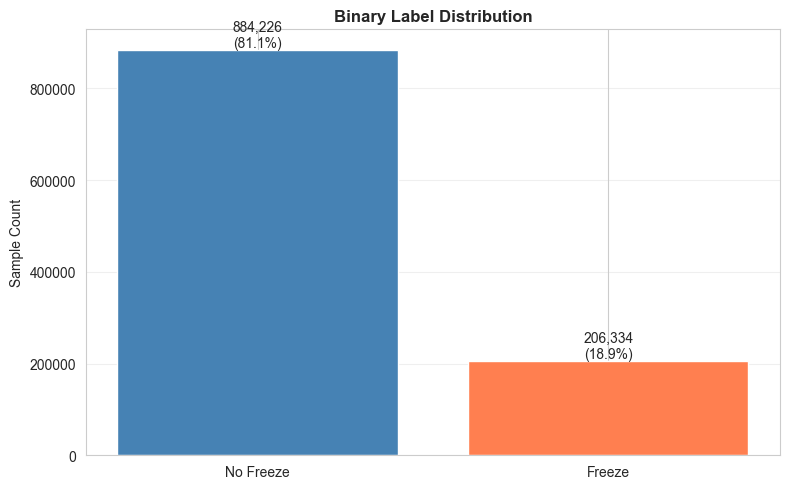

In [4]:
# Visualize label distribution
fig, ax = plt.subplots(figsize=(8, 5))

binary_counts = df['binary_label'].value_counts().sort_index()
ax.bar(['No Freeze', 'Freeze'], binary_counts.values, color=['steelblue', 'coral'])
ax.set_ylabel('Sample Count')
ax.set_title('Binary Label Distribution', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, v in enumerate(binary_counts.values):
    pct = v / len(df) * 100
    ax.text(i, v, f'{v:,}\n({pct:.1f}%)', ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 3. Define Feature Columns and Parameters

In [5]:
# Figshare-specific parameters
SAMPLING_RATE = 64  # Hz
WINDOW_SIZE_SEC = 4.0  # seconds
WINDOW_OVERLAP_TRAIN = 0.5  # 50% overlap for training
WINDOW_OVERLAP_TEST = 0.0  # 0% overlap for testing

# Feature columns: accelerometer + gyroscope
FEATURE_COLUMNS = [
    'acc_ml_g', 'acc_ap_g', 'acc_si_g',
    'gyr_ml_deg_s', 'gyr_ap_deg_s', 'gyr_si_deg_s'
]

print("Configuration:")
print(f"  Sampling rate: {SAMPLING_RATE} Hz")
print(f"  Window size: {WINDOW_SIZE_SEC} seconds ({int(WINDOW_SIZE_SEC * SAMPLING_RATE)} samples)")
print(f"  Features: {len(FEATURE_COLUMNS)}")
print(f"  Train overlap: {WINDOW_OVERLAP_TRAIN*100}%")
print(f"  Test overlap: {WINDOW_OVERLAP_TEST*100}%")

Configuration:
  Sampling rate: 64 Hz
  Window size: 4.0 seconds (256 samples)
  Features: 6
  Train overlap: 50.0%
  Test overlap: 0.0%


## 4. Create Sliding Windows for Visualization

In [6]:
# Create window creator for visualization
window_creator = WindowCreator(
    window_size=WINDOW_SIZE_SEC,
    overlap=WINDOW_OVERLAP_TRAIN,
    sampling_rate=SAMPLING_RATE
)

# Display configuration
config = window_creator.get_window_info()
print("Window Configuration:")
print(f"  Duration: {config['window_size_sec']} seconds")
print(f"  Samples: {config['window_samples']}")
print(f"  Overlap: {config['overlap']*100}%")
print(f"  Step: {config['step_samples']} samples")

Window Configuration:
  Duration: 4.0 seconds
  Samples: 256
  Overlap: 50.0%
  Step: 128 samples


In [7]:
# Create windows for one subject (visualization)
subject_sample = 'S01'
df_sample = df[df['subject'] == subject_sample].reset_index(drop=True)

windows_sample, labels_sample, subjects_sample = window_creator.create_windows_per_subject(
    df=df_sample,
    feature_cols=FEATURE_COLUMNS,
    label_col='binary_label',
    subject_col='subject',
    trial_col='session'
)

print(f"\nSample windows created for {subject_sample}:")
print(f"  Windows shape: {windows_sample.shape}")
print(f"  Label distribution: {np.bincount(labels_sample)}")


Sample windows created for S01:
  Windows shape: (238, 256, 6)
  Label distribution: [  8 230]


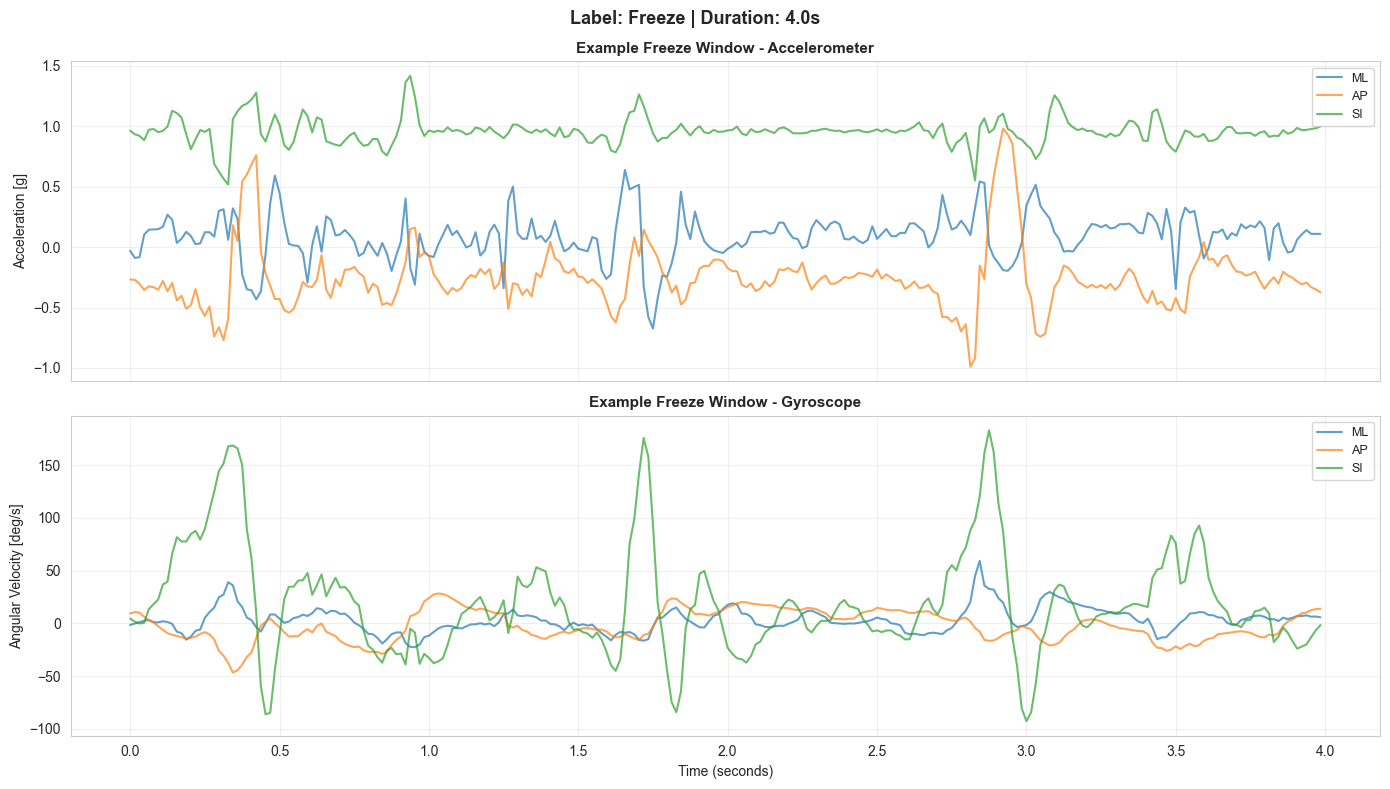

In [8]:
# Visualize example window
freeze_indices = np.where(labels_sample == 1)[0]
if len(freeze_indices) > 0:
    idx = freeze_indices[0]
    example_window = windows_sample[idx]
    example_label = labels_sample[idx]
    
    n_samples, n_channels = example_window.shape
    time_axis = np.arange(n_samples) / SAMPLING_RATE
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    # Accelerometer
    axes[0].plot(time_axis, example_window[:, 0], label='ML', alpha=0.7)
    axes[0].plot(time_axis, example_window[:, 1], label='AP', alpha=0.7)
    axes[0].plot(time_axis, example_window[:, 2], label='SI', alpha=0.7)
    axes[0].set_ylabel('Acceleration [g]')
    axes[0].set_title('Example Freeze Window - Accelerometer', fontsize=11, fontweight='bold')
    axes[0].legend(loc='upper right', fontsize=9)
    axes[0].grid(True, alpha=0.3)
    
    # Gyroscope
    axes[1].plot(time_axis, example_window[:, 3], label='ML', alpha=0.7)
    axes[1].plot(time_axis, example_window[:, 4], label='AP', alpha=0.7)
    axes[1].plot(time_axis, example_window[:, 5], label='SI', alpha=0.7)
    axes[1].set_ylabel('Angular Velocity [deg/s]')
    axes[1].set_xlabel('Time (seconds)')
    axes[1].set_title('Example Freeze Window - Gyroscope', fontsize=11, fontweight='bold')
    axes[1].legend(loc='upper right', fontsize=9)
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle(f'Label: Freeze | Duration: {WINDOW_SIZE_SEC}s', 
                fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No freeze windows found in sample.")

## 5. Create LOSO Splits with Different Overlap for Train/Test

**Strategy:**
- **Train windows:** 50% overlap (more training data)
- **Test windows:** 0% overlap (realistic evaluation, no temporal correlation)

This ensures proper evaluation without overestimating performance due to overlapping windows in test set.

In [9]:
# Create LOSO splits with different overlap for train/test
print("Creating LOSO splits with different overlap strategies...")
print("  Train: 50% overlap (more data)")
print("  Test: 0% overlap (realistic evaluation)")
print("="*70)

# Get unique subjects
subjects = sorted(df['subject'].unique())
n_splits = len(subjects)

# Create window creators
window_creator_train = WindowCreator(
    window_size=WINDOW_SIZE_SEC,
    overlap=WINDOW_OVERLAP_TRAIN,
    sampling_rate=SAMPLING_RATE
)

window_creator_test = WindowCreator(
    window_size=WINDOW_SIZE_SEC,
    overlap=WINDOW_OVERLAP_TEST,
    sampling_rate=SAMPLING_RATE
)

loso_splits_binary = []

for fold, test_subject in enumerate(subjects):
    print(f"\nFold {fold}: Test Subject = {test_subject}")
    
    # Split dataframe into train and test subjects
    train_subjects = [s for s in subjects if s != test_subject]
    
    df_train = df[df['subject'].isin(train_subjects)].reset_index(drop=True)
    df_test = df[df['subject'] == test_subject].reset_index(drop=True)
    
    # Create train windows with 50% overlap
    X_train_windows, y_train, train_subjects_arr = window_creator_train.create_windows_per_subject(
        df=df_train,
        feature_cols=FEATURE_COLUMNS,
        label_col='binary_label',
        subject_col='subject',
        trial_col='session'
    )
    
    # Create test windows with 0% overlap
    X_test_windows, y_test, test_subjects_arr = window_creator_test.create_windows_per_subject(
        df=df_test,
        feature_cols=FEATURE_COLUMNS,
        label_col='binary_label',
        subject_col='subject',
        trial_col='session'
    )
    
    # Create split info
    split_info = {
        'fold': fold,
        'test_subject': test_subject,
        'X_train': X_train_windows,
        'X_test': X_test_windows,
        'y_train': y_train,
        'y_test': y_test,
        'subjects_train': train_subjects_arr,
        'subjects_test': test_subjects_arr,
        'train_dist': np.bincount(y_train, minlength=2),
        'test_dist': np.bincount(y_test, minlength=2)
    }
    loso_splits_binary.append(split_info)
    
    print(f"  Train: {X_train_windows.shape[0]} windows (50% overlap)")
    print(f"  Test:  {X_test_windows.shape[0]} windows (0% overlap)")
    print(f"  Train distribution: {split_info['train_dist']}")
    print(f"  Test distribution:  {split_info['test_dist']}")

print("\n" + "="*70)
print(f"Binary LOSO splits created: {len(loso_splits_binary)} folds")
print("="*70)

Creating LOSO splits with different overlap strategies...
  Train: 50% overlap (more data)
  Test: 0% overlap (realistic evaluation)

Fold 0: Test Subject = S01
  Train: 8211 windows (50% overlap)
  Test:  120 windows (0% overlap)
  Train distribution: [6841 1370]
  Test distribution:  [  4 116]

Fold 1: Test Subject = S02
  Train: 8330 windows (50% overlap)
  Test:  60 windows (0% overlap)
  Train distribution: [6837 1493]
  Test distribution:  [ 7 53]

Fold 2: Test Subject = S03
  Train: 8092 windows (50% overlap)
  Test:  180 windows (0% overlap)
  Train distribution: [6494 1598]
  Test distribution:  [179   1]

Fold 3: Test Subject = S04
  Train: 8330 windows (50% overlap)
  Test:  60 windows (0% overlap)
  Train distribution: [6746 1584]
  Test distribution:  [49 11]

Fold 4: Test Subject = S05
  Train: 8211 windows (50% overlap)
  Test:  120 windows (0% overlap)
  Train distribution: [6633 1578]
  Test distribution:  [110  10]

Fold 5: Test Subject = S06
  Train: 8211 windows (50

## 6. Visualize LOSO Splits

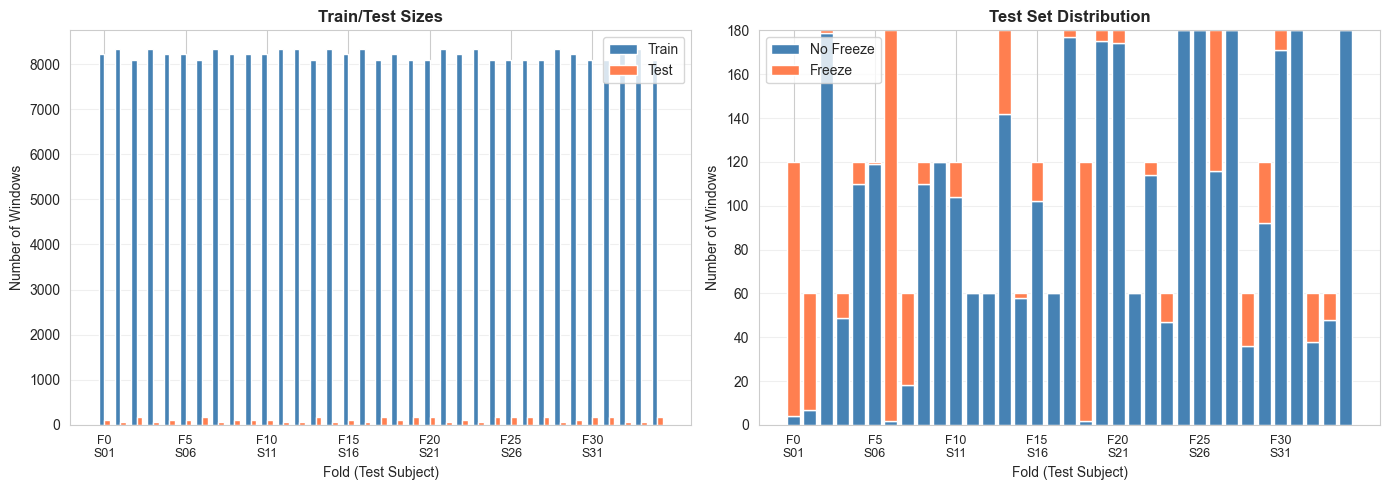

In [10]:
# Visualize LOSO splits
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train/Test sizes
train_sizes = [split['X_train'].shape[0] for split in loso_splits_binary]
test_sizes = [split['X_test'].shape[0] for split in loso_splits_binary]
test_subjects = [split['test_subject'] for split in loso_splits_binary]

x = np.arange(len(loso_splits_binary))
width = 0.35

axes[0].bar(x - width/2, train_sizes, width, label='Train', color='steelblue')
axes[0].bar(x + width/2, test_sizes, width, label='Test', color='coral')
axes[0].set_xlabel('Fold (Test Subject)')
axes[0].set_ylabel('Number of Windows')
axes[0].set_title('Train/Test Sizes', fontweight='bold')
axes[0].set_xticks(x[::5])
axes[0].set_xticklabels([f"F{i}\n{test_subjects[i]}" for i in range(0, len(test_subjects), 5)], fontsize=9)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Test distribution
for i, split in enumerate(loso_splits_binary):
    dist = split['test_dist']
    axes[1].bar(i, dist[0], color='steelblue', label='No Freeze' if i == 0 else '')
    axes[1].bar(i, dist[1], bottom=dist[0], color='coral', label='Freeze' if i == 0 else '')

axes[1].set_xlabel('Fold (Test Subject)')
axes[1].set_ylabel('Number of Windows')
axes[1].set_title('Test Set Distribution', fontweight='bold')
axes[1].set_xticks(range(0, len(loso_splits_binary), 5))
axes[1].set_xticklabels([f"F{i}\n{test_subjects[i]}" for i in range(0, len(test_subjects), 5)], fontsize=9)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Summary Statistics

In [11]:
# Summary
total_train_bin = sum([split['X_train'].shape[0] for split in loso_splits_binary])
total_test_bin = sum([split['X_test'].shape[0] for split in loso_splits_binary])

print("="*70)
print("PREPROCESSING SUMMARY")
print("="*70)

print(f"\nOriginal dataset:")
print(f"  Samples: {len(df):,}")
print(f"  Subjects: {df['subject'].nunique()}")

print(f"\nWindow creation strategy:")
print(f"  Train windows: {WINDOW_SIZE_SEC}s, 50% overlap")
print(f"  Test windows: {WINDOW_SIZE_SEC}s, 0% overlap (no temporal correlation)")
print(f"  Window shape: ({int(WINDOW_SIZE_SEC * SAMPLING_RATE)} samples, {len(FEATURE_COLUMNS)} features)")

print(f"\nLOSO splits:")
print(f"  Folds: {len(loso_splits_binary)}")
print(f"  Avg train windows/fold: {total_train_bin/len(loso_splits_binary):.0f}")
print(f"  Avg test windows/fold: {total_test_bin/len(loso_splits_binary):.0f}")

print(f"\nClass balance (binary):")
train_no_freeze = sum([split['train_dist'][0] for split in loso_splits_binary])
train_freeze = sum([split['train_dist'][1] for split in loso_splits_binary])
test_no_freeze = sum([split['test_dist'][0] for split in loso_splits_binary])
test_freeze = sum([split['test_dist'][1] for split in loso_splits_binary])

print(f"  Train - No Freeze: {train_no_freeze:,} ({train_no_freeze/(train_no_freeze+train_freeze)*100:.1f}%)")
print(f"  Train - Freeze: {train_freeze:,} ({train_freeze/(train_no_freeze+train_freeze)*100:.1f}%)")
print(f"  Test - No Freeze: {test_no_freeze:,} ({test_no_freeze/(test_no_freeze+test_freeze)*100:.1f}%)")
print(f"  Test - Freeze: {test_freeze:,} ({test_freeze/(test_no_freeze+test_freeze)*100:.1f}%)")

print("="*70)

PREPROCESSING SUMMARY

Original dataset:
  Samples: 1,090,560
  Subjects: 35

Window creation strategy:
  Train windows: 4.0s, 50% overlap
  Test windows: 4.0s, 0% overlap (no temporal correlation)
  Window shape: (256 samples, 6 features)

LOSO splits:
  Folds: 35
  Avg train windows/fold: 8208
  Avg test windows/fold: 122

Class balance (binary):
  Train - No Freeze: 232,866 (81.1%)
  Train - Freeze: 54,400 (18.9%)
  Test - No Freeze: 3,454 (81.1%)
  Test - Freeze: 806 (18.9%)


## 8. Save Processed Data

In [12]:
# Create output directory
output_dir = Path('../../outputs/datasets_csv')
output_dir.mkdir(parents=True, exist_ok=True)

# Save labeled dataset
csv_path = output_dir / 'figshare_segmented_dataset.csv'
df.to_csv(csv_path, index=False)
print(f"Labeled dataset saved: {csv_path}")
print(f"  Samples: {len(df):,}")
print(f"  Columns: {len(df.columns)}")

# Save binary LOSO splits
binary_path = output_dir / 'figshare_loso_windows_binary.pkl'
with open(binary_path, 'wb') as f:
    pickle.dump(loso_splits_binary, f)
print(f"\nBinary LOSO splits saved: {binary_path}")
print(f"  Folds: {len(loso_splits_binary)}")
print(f"  Total windows: {sum([len(s['y_train']) + len(s['y_test']) for s in loso_splits_binary]):,}")

print("\n" + "="*70)
print("All data saved successfully.")
print("="*70)

Labeled dataset saved: ../../outputs/datasets_csv/figshare_segmented_dataset.csv
  Samples: 1,090,560
  Columns: 17

Binary LOSO splits saved: ../../outputs/datasets_csv/figshare_loso_windows_binary.pkl
  Folds: 35
  Total windows: 291,526

All data saved successfully.


## Summary

**Completed preprocessing pipeline:**

1. Loaded Figshare dataset (walking trials, 64 Hz sampling)
2. Used existing binary labels (0=No Freeze, 1=Freeze)
3. Generated sliding windows with different overlap strategies:
   - **Train: 50% overlap** (more training data, 128-sample steps)
   - **Test: 0% overlap** (realistic evaluation, 256-sample steps)
4. Created 35 LOSO folds for subject-independent validation
5. Saved labeled dataset and windowed LOSO splits

**Rationale for different overlap:**
- 50% overlap in training provides more diverse training examples
- 0% overlap in testing avoids temporal correlation between test windows
- This prevents overestimating model performance due to overlapping predictions

**Data structure:**
- Train windows: shape (n_windows, 256, 6) with 50% overlap
- Test windows: shape (n_windows, 256, 6) with 0% overlap
- Windows maintain temporal continuity within subject/session boundaries
- No data leakage: test subjects completely isolated in each fold

**Next step:** Feature extraction from windowed data (notebook 03)